# ข้อละ 1 คะแนน เต็ม 10 คะแนน
## <font color=byellow> ไฟล์ car.csv ไฟล์ ประกอบด้วย attribute ดังนี้
- ### <font color=blue> Car : ยี่ห้อรถยนต์
- ### <font color=blue> Model : รุ่นของรถยนต์
- ### <font color=blue> Volume : ขนาดกระบอกสููบ
- ### <font color=blue> Weight : นำ้หนักรถยนต์
- ### <font color=blue> CO2 : ปรืมาณคาร์บอนไดออกไซด์ที่รถยนต์ปล่อยออกมา   ¶

In [15]:
import pandas as pd
import statsmodels.formula.api as sm
from sklearn import linear_model

import matplotlib.pyplot as plt
%matplotlib inline 

In [6]:
advert = pd.read_csv('cars.csv')
advert.head()

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


In [12]:
#1.เขียนโปรแกรมพิมพ์ค่าสถิติพื้นฐานของข้อมูลจากไฟล์
advert.describe()

,Volume,Weight,CO2
count,36.000000,36.000000,36.000000
mean,1611.111111,1292.277778,102.027778
std,388.975047,242.123889,7.454571
min,900.000000,790.000000,90.000000
25%,1475.000000,1117.250000,97.750000
50%,1600.000000,1329.000000,99.000000
75%,2000.000000,1418.250000,105.000000
max,2500.000000,1746.000000,120.000000


In [17]:
#2.พิมพ์ค่า correlation ของตัวแปร
print(advert.corr(numeric_only=True))

          Volume    Weight       CO2
Volume  1.000000  0.753537  0.592082
Weight  0.753537  1.000000  0.552150
CO2     0.592082  0.552150  1.000000


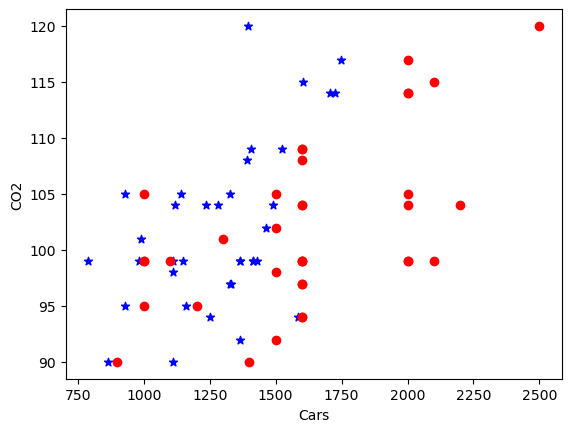

In [30]:
#3. plot scatter plot เพื่อดูความสัมพันธ์ระหว่าง CO2, Weight, Volume  
#โดยมีกราฟชื่อ CO2 Emission แกน Y ชื่อ CO2 และแกน X ชื่อ Cars
plt.scatter(x=advert['Weight'],y=advert['CO2'],c='b',marker='*',label='Weight')
plt.scatter(x=advert['Volume'],y=advert['CO2'],c='r',marker='o',label='Volume')

plt.xlabel('Cars')
plt.ylabel('CO2')
plt.show()

In [20]:
#4.พิจารณาตัวแปร Volume และ CO2 โดยใช้ linear regression model
ad_Volume_ols = sm.ols(formula="CO2 ~ Volume", data=advert).fit()
ad_Volume_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CO2   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     18.35
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           0.000142
Time:                        09:26:44   Log-Likelihood:                -115.12
No. Observations:                  36   AIC:                             234.2
Df Residuals:                      34   BIC:                             237.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     83.7464      4.387     19.092      0.000      74.832      92.661
Volume         0.0113      0.003      4.284      0.000       0.006       0.017
==============================================================================
Omnibus:                        7.658   Durbin-Watson:                   0.958
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                2.261
Skew:                           0.076   Prob(JB):                        0.323
Kurtosis:                       1.782   Cond. No.                     7.15e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.15e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

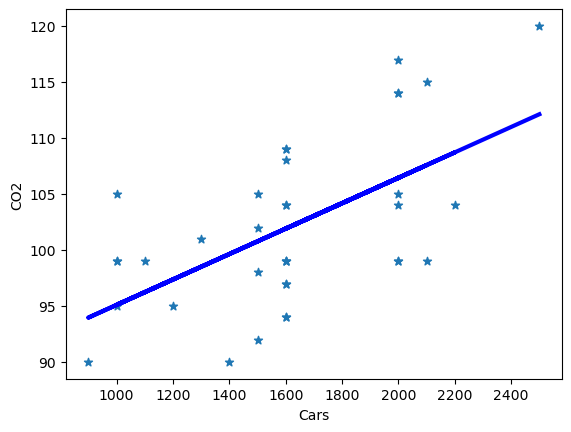

In [40]:
#5.plot กราฟ เพื่อดูความสัมพันธ์ของตัวแปร Volume และ CO2 ที่อยู่ในโจทย์ข้อ 4 
# แสดงเส้นพยากรณ์ของความสัมพันธ์ของ 2 ตัวแปร
#นศ.ต้องพิจารณาวเองว่าตัวแปรไหนเป็นตัวแปร x อิสระ และตัวแปรตาม
plt.scatter(x=advert['Volume'],y=advert['CO2'],marker='*',label='Volume')


plt.plot(advert['Volume'],ad_Volume_ols.predict(),color='blue',linewidth=3)

plt.xlabel('Cars')
plt.ylabel('CO2')
plt.show()

In [29]:
#6. แสดงผลค่า R-squared, coef, Intercept
# เขียนสมการของเส้นพยากรณ์ของตัวแปร Volume และ CO2
ad_Volume_ols = sm.ols(formula="CO2 ~ Volume", data=advert).fit()
ad_Volume_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CO2   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     18.35
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           0.000142
Time:                        09:32:23   Log-Likelihood:                -115.12
No. Observations:                  36   AIC:                             234.2
Df Residuals:                      34   BIC:                             237.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     83.7464      4.387     19.092      0.000      74.832      92.661
Volume         0.0113      0.003      4.284      0.000       0.006       0.017
==============================================================================
Omnibus:                        7.658   Durbin-Watson:                   0.958
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                2.261
Skew:                           0.076   Prob(JB):                        0.323
Kurtosis:                       1.782   Cond. No.                     7.15e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.15e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### เขียนสมการตรงนี้ CO2 = B0 + B1*Volume   
83.7464 + 0.0113Volume


In [32]:
#7.พิจารณาตัวแปร Weight กับ CO2  โดยใช้ linear regression model
ad_Weight_ols = sm.ols(formula = "CO2~ Weight", data = advert).fit()
ad_Weight_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CO2   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     14.91
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           0.000481
Time:                        09:35:41   Log-Likelihood:                -116.35
No. Observations:                  36   AIC:                             236.7
Df Residuals:                      34   BIC:                             239.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     80.0594      5.785     13.839      0.000      68.302      91.816
Weight         0.0170      0.004      3.862      0.000       0.008       0.026
==============================================================================
Omnibus:                        0.226   Durbin-Watson:                   0.988
Prob(Omnibus):                  0.893   Jarque-Bera (JB):                0.104
Skew:                           0.122   Prob(JB):                        0.949
Kurtosis:                       2.901   Cond. No.                     7.23e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.23e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

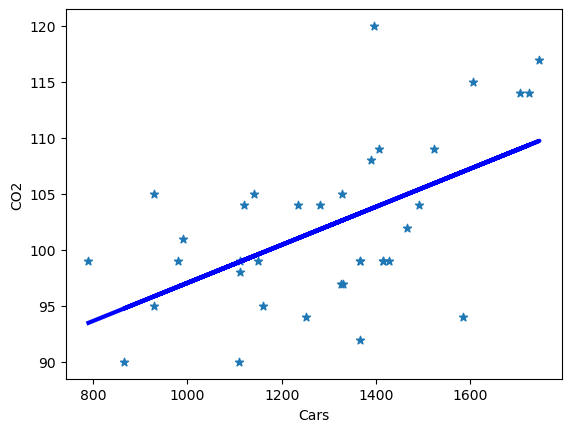

In [39]:
#8.plot กราฟ เพื่อดูความสัมพันธ์ของตัวแปร Weight และ CO2 ที่อยู่ในโจทย์ข้อ 7
# แสดงเส้นพยากรณ์ของความสัมพันธ์ของ 2 ตัวแปร
plt.scatter(x=advert['Weight'],y=advert['CO2'],marker='*',label='Weight')


plt.plot(advert['Weight'],ad_Weight_ols.predict(),color='blue',linewidth=3)

plt.xlabel('Cars')
plt.ylabel('CO2')
plt.show()

In [38]:
#9. แสดงผลค่า R-squared, coef, Intercept
# เขียนสมการของเส้นพยากรณ์ของตัวแปร Weight และ CO2
ad_Weight_ols = sm.ols(formula = "CO2 ~ Weight", data = advert).fit()
ad_Weight_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CO2   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     14.91
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           0.000481
Time:                        09:38:12   Log-Likelihood:                -116.35
No. Observations:                  36   AIC:                             236.7
Df Residuals:                      34   BIC:                             239.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     80.0594      5.785     13.839      0.000      68.302      91.816
Weight         0.0170      0.004      3.862      0.000       0.008       0.026
==============================================================================
Omnibus:                        0.226   Durbin-Watson:                   0.988
Prob(Omnibus):                  0.893   Jarque-Bera (JB):                0.104
Skew:                           0.122   Prob(JB):                        0.949
Kurtosis:                       2.901   Cond. No.                     7.23e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.23e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### เขียนสมการตรงนี้ CO2 = B0 + B1 * Weight
80.0594 + 0.0170Weight

In [62]:
#10. พิจารณาตัวแปร Volume, Weight และ CO2 โดยใช้ linear regression model
# แสดงผลค่า R-squared, coef, Intercept
# เขียนสมการของเส้นพยากรณ์ของตัวแปร Volume, Weight และ CO2
ad_all_ols = sm.ols(formula = "CO2 ~ Volume + Weight", data = advert).fit()
ad_all_ols.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CO2   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     9.966
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           0.000411
Time:                        10:04:05   Log-Likelihood:                -114.39
No. Observations:                  36   AIC:                             234.8
Df Residuals:                      33   BIC:                             239.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     79.6947      5.564     14.322      0.000      68.374      91.016
Volume         0.0078      0.004      1.948      0.060      -0.000       0.016
Weight         0.0076      0.006      1.173      0.249      -0.006       0.021
==============================================================================
Omnibus:                        4.957   Durbin-Watson:                   0.944
Prob(Omnibus):                  0.084   Jarque-Bera (JB):                1.836
Skew:                          -0.025   Prob(JB):                        0.399
Kurtosis:                       1.895   Cond. No.                     1.16e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

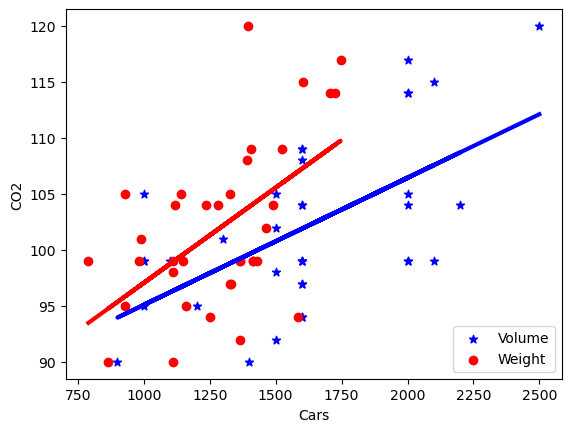

In [61]:
plt.scatter(x=advert['Volume'],y=advert['CO2'],c= 'blue',marker='*',label='Volume')
plt.scatter(x=advert['Weight'],y=advert['CO2'],c='red',marker='o',label='Weight')
plt.legend(numpoints=1,loc=4)

plt.plot(advert['Volume'],ad_Volume_ols.predict(),color='blue',linewidth=3)
plt.plot(advert['Weight'],ad_Weight_ols.predict(),color='red',linewidth=3)

plt.xlabel('Cars')
plt.ylabel('CO2')
plt.show()

### <font color=green>  ตอบตรงนี้ สมการสุดท้ายคือ. CO2 = B0 + B1*Volume + B2 * Weight 

79.6947 + 0.0078Volume + 0.0076Weight